# AI-Assisted Image Reconstruction for Radiation Dose Reduction in Computed Tomography

Denoises low-dose ("quarter dose") CT images to approach normal-dose image quality, using RED-CNN
(Chen et al., 2017) trained on the 2016 NIH-AAPM-Mayo Clinic Low Dose CT Grand Challenge dataset.

**Scope note:** this denoises already-reconstructed images (image domain), not raw sinogram/projection
data -- see the design decisions below for why.

## Design decisions and rejected alternatives

Full reasoning for each of these is in `design_decisions.md`; summarized here for anyone reading the
notebook on its own.

| Decision | Chosen | Rejected | Why (short version) |
|---|---|---|---|
| Scope | Image-domain denoising | Sinogram-domain reconstruction | Raw projection data isn't available here; denoising is the tractable, actually-available problem |
| Model | RED-CNN (plain CNN) | GAN (WGAN-VGG style) | A fully-understood CNN, including its known over-smoothing limitation, beats a GAN result that isn't fully explainable on a first attempt |
| Kernel | Sharp (D45) | Soft (B30) | D45's noise is closer to random/independent, matching what a per-pixel MSE loss assumes |
| Slice thickness | 1mm | 3mm | More slices per patient; 3mm Full Dose was also missing for all 10 patients in this Kaggle mirror |
| Data source | Raw DICOM (`Original Data`) | `Preprocessed_*` folders | Confirmed empirically that the preprocessed PNGs use per-scan-adaptive scaling, not a fixed window |
| HU window | Clip [-160, 240], then min-max to [0,1] | Z-score standardization | Clinically meaningful range for abdominal CT; avoids distortion from metal/contrast HU outliers |
| Patch strategy | Random 64x64 crops, on the fly | Original paper's 55x55 regular-interval sliding window | Simpler `Dataset`; a documented simplification also used in at least one public reimplementation |
| Data loading | Preload all slices into RAM once | Lazy-load + LRU cache per access | Fits comfortably in RAM; removes disk I/O from the training loop; makes safe multi-worker loading possible |
| Learning rate | 1e-4 (the paper's original value), tested rather than assumed | Higher rates (5e-4, 1e-3) | The literature disagrees on the right LR for RED-CNN (1e-5 to 5e-4 across reimplementations), so this was checked empirically rather than trusted by default -- a sweep initially favored higher rates, but a full-scale run showed that was a scale artifact; 1e-4 turned out fine |
| Precision / compile | Plain float32, eager mode | Mixed precision (AMP), `torch.compile`, `channels_last` | See "Performance notes" below -- some of these were tested and reverted for real correctness/compatibility risk, not just left out |
| Train/val/test split | Fixed patient split (see below) | Full leave-one-patient-out cross-validation (as in the original paper) | 10x cheaper to run; appropriate for a portfolio piece, explicitly noted as a rigor tradeoff |


## Performance notes

A few speed optimizations were tried and deliberately **not** kept, for reasons worth stating rather
than leaving unexplained:

- **`torch.compile`**: not used. There's an open PyTorch issue specifically about Pascal-generation
  GPUs (which includes the P100 Kaggle sometimes assigns) needing workarounds for Triton/TorchInductor
  support -- not a safe default when the notebook needs to run reliably regardless of which GPU Kaggle
  hands out.
- **`channels_last` memory format**: not used. There's a confirmed PyTorch bug report of `channels_last`
  producing *silently wrong output* specifically for `ConvTranspose2d` layers -- RED-CNN has five of
  them. A speed optimization that risks silently invalid results has no place in a project whose whole
  point is defensible results.
- **Mixed precision (AMP)**: not used, by choice rather than oversight. It's a genuine speedup on
  tensor-core GPUs, but it adds real conceptual and code overhead (`autocast`, `GradScaler`,
  scale/unscale semantics) for a beginner-friendly, portfolio-readable notebook. If you want to add it
  back, it's a small, well-documented change -- but it's opt-in here, not default.
- **Preloading the dataset onto the GPU** (not just RAM): not used. The training set alone is close to
  the VRAM ceiling on a 16GB GPU once you add the model, activations, and gradients -- a real
  out-of-memory risk for a modest, uncertain gain, and it adds a non-trivial amount of code.

What *is* kept, because it's genuinely safe and simple: `cudnn.benchmark=True` (one line, no risk,
since every patch is the same fixed size), `fused=True` on the Adam optimizer (a supported, low-risk
kwarg), batching validation instead of looping image-by-image (verified to produce numerically
identical results, just faster), and accumulating the training loss on the GPU instead of forcing a
CPU sync every batch.

A second round of suggestions came up later, worth addressing directly rather than silently ignoring:
`torch.compile` and `channels_last` were suggested again -- still not used, for the same reasons above,
not because they were overlooked. Storing only metric values instead of full image arrays for every
evaluated slice *was* adopted (the `evaluate`/`predict_one` split below) -- holding arrays for over a
thousand images just in case a few get plotted was a real, unnecessary memory cost. A few others
(precomputing crop coordinates, splitting the dataset into separate lists instead of paired tuples,
building a dedicated validation DataLoader) were considered and skipped: each was either a marginal
gain (a couple of percent, by the suggestion's own estimate) not worth the added code, or based on a
performance assumption that doesn't hold up here (e.g. Python tuples aren't meaningfully slower to
index than separate lists).

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pydicom
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True  # every crop is 64x64, no variable input sizes here

## Locating the dataset

This exact path has been confirmed stable across every run of this project. The one real surprise
during development was internal -- `Original Data` isn't a sibling of `metadata.csv` the way it first
appeared -- not the root mount path itself, which has never changed. So this is a direct path, not a
search: simpler to read, and not defending against a risk that was never actually observed here.

In [2]:
ORIG_ROOT = (Path("/kaggle/input/datasets/andrewmvd/ct-low-dose-reconstruction")
             / "CT_low_dose_reconstruction_dataset" / "Original Data")

if not ORIG_ROOT.exists():
    raise FileNotFoundError(
        f"Expected the dataset at {ORIG_ROOT}, but it's not there. Run "
        "os.listdir('/kaggle/input') (and its subfolders) to find where it "
        "actually landed this time, then update ORIG_ROOT above."
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dataset found:", ORIG_ROOT)
print("Device:", device)

Dataset found: /kaggle/input/datasets/andrewmvd/ct-low-dose-reconstruction/CT_low_dose_reconstruction_dataset/Original Data
Device: cuda


In [3]:
THICKNESS = "1mm Slice Thickness"
KERNEL = "Sharp Kernel (D45)"
HU_WINDOW = (-160, 240)
PATCH_SIZE = 64

# fixed split, not k-fold like the paper (design_decisions.md has the full reasoning)
TRAIN_PATIENTS = ["L067", "L096", "L109", "L143", "L192", "L286", "L291"]
VAL_PATIENTS   = ["L310"]
TEST_PATIENTS  = ["L333", "L506"]

SMOKE_TEST = False  # True = tiny subset, runs in ~1-2 min, just to catch broken code early

## Dataset

Loads every paired (Full Dose, Quarter Dose) slice into RAM once, as normalized `[0,1]` tensors,
matched by DICOM `InstanceNumber`. `__getitem__` then just slices a random 64x64 crop out of an
already-loaded tensor -- no disk I/O, no DICOM parsing, during training.

**RAM cost**: full training set (~4,300 pairs) is roughly 8-9GB. If that doesn't fit your session,
train on fewer patients or lower `max_slices`, rather than going back to lazy loading -- that
reintroduces the exact throughput problem solved here.

Crop coordinates use plain Python `random`, not `torch.randint` -- creating a tiny tensor for a single
random number, tens of thousands of times per epoch, has measurably more overhead than plain Python
for something this small.

In [4]:
def instance_number(path):
    # L067_FD_1_SHARP_1.CT.0002.0001.2016.01.21...IMA -> instance = 0001
    return int(path.name.split(".")[3])


def load_hu(path):
    ds = pydicom.dcmread(path, force=True)
    return ds.pixel_array.astype(np.float32) * float(ds.RescaleSlope) + float(ds.RescaleIntercept)


class LDCTPatchDataset(Dataset):
    def __init__(self, root, patient_ids, thickness=THICKNESS, kernel=KERNEL,
                 patch_size=PATCH_SIZE, hu_window=HU_WINDOW, patches_per_slice=8,
                 max_slices=None):
        self.patch_size = patch_size
        self.patches_per_slice = patches_per_slice
        hu_low, hu_high = hu_window
        self.images = []

        print(f"Loading {len(patient_ids)} patients into RAM...")
        for patient in patient_ids:
            fd_dir = root / "Full Dose" / thickness / kernel / patient
            qd_dir = root / "Quarter Dose" / thickness / kernel / patient
            if not fd_dir.is_dir() or not qd_dir.is_dir():
                raise RuntimeError(f"Missing folders for {patient}: expected {fd_dir} and {qd_dir}")

            fd_files = {instance_number(f): f for f in fd_dir.glob("*.IMA")}
            qd_files = {instance_number(f): f for f in qd_dir.glob("*.IMA")}
            common = sorted(set(fd_files) & set(qd_files))
            if not common:
                raise ValueError(f"No overlapping slice indices for patient {patient}")
            if max_slices is not None:
                common = common[:max_slices]

            for idx in common:
                # clip to the abdominal HU window, then rescale to [0,1]
                fd = np.clip(load_hu(fd_files[idx]), hu_low, hu_high)
                qd = np.clip(load_hu(qd_files[idx]), hu_low, hu_high)
                fd = (fd - hu_low) / (hu_high - hu_low)
                qd = (qd - hu_low) / (hu_high - hu_low)
                fd_t = torch.from_numpy(fd).unsqueeze(0).float()
                qd_t = torch.from_numpy(qd).unsqueeze(0).float()
                self.images.append((qd_t, fd_t))  # (LDCT input, NDCT target)

        print(f"Loaded {len(self.images)} paired slices.")

    def __len__(self):
        return len(self.images) * self.patches_per_slice  # patches_per_slice random crops per slice, per epoch

    def __getitem__(self, idx):
        qd, fd = self.images[idx // self.patches_per_slice]
        _, h, w = qd.shape
        ps = self.patch_size
        top = random.randint(0, h - ps)
        left = random.randint(0, w - ps)
        return qd[:, top:top + ps, left:left + ps], fd[:, top:top + ps, left:left + ps]


if SMOKE_TEST:
    train_ds = LDCTPatchDataset(ORIG_ROOT, TRAIN_PATIENTS[:2], patches_per_slice=2, max_slices=20)
    val_ds   = LDCTPatchDataset(ORIG_ROOT, VAL_PATIENTS,        patches_per_slice=1, max_slices=10)
    test_ds  = LDCTPatchDataset(ORIG_ROOT, TEST_PATIENTS[:1],   patches_per_slice=1, max_slices=10)
else:
    train_ds = LDCTPatchDataset(ORIG_ROOT, TRAIN_PATIENTS, patches_per_slice=8)
    val_ds   = LDCTPatchDataset(ORIG_ROOT, VAL_PATIENTS,   patches_per_slice=1)
    test_ds  = LDCTPatchDataset(ORIG_ROOT, TEST_PATIENTS,  patches_per_slice=1)

print(f"\n{'SMOKE TEST' if SMOKE_TEST else 'FULL RUN'}")
print(f"train: {len(train_ds.images)} slices, {len(train_ds):,} virtual patches")
print(f"val:   {len(val_ds.images)} slices")
print(f"test:  {len(test_ds.images)} slices")

Loading 7 patients into RAM...
Loaded 4267 paired slices.
Loading 1 patients into RAM...
Loaded 533 paired slices.
Loading 2 patients into RAM...
Loaded 1136 paired slices.

FULL RUN
train: 4267 slices, 34,136 virtual patches
val:   533 slices
test:  1136 slices


## Baseline: how bad is the problem with no model at all?

Every later result should be reported relative to this, not in isolation. Will look low next to papers
using a wider HU window for their PSNR calculation -- that's a normalization difference, not
necessarily a data quality difference; see the critical discussion at the end.

In [5]:
def compute_baseline(dataset, n_samples=30):
    n = min(n_samples, len(dataset.images))
    psnrs, ssims = [], []
    for qd, fd in dataset.images[:n]:
        qd_np, fd_np = qd.squeeze().numpy(), fd.squeeze().numpy()
        psnrs.append(psnr_fn(fd_np, qd_np, data_range=1.0))
        ssims.append(ssim_fn(fd_np, qd_np, data_range=1.0))
    return float(np.mean(psnrs)), float(np.mean(ssims))


baseline_psnr, baseline_ssim = compute_baseline(val_ds)
print(f"Baseline PSNR: {baseline_psnr:.2f} dB")
print(f"Baseline SSIM: {baseline_ssim:.4f}")

Baseline PSNR: 17.02 dB
Baseline SSIM: 0.6734


## Model: RED-CNN

Chen et al., 2017 (arXiv:1702.00288). 10 layers (5 conv + 5 deconv), symmetric, kernel 5x5, stride 1,
no padding, no pooling -- pooling was found in the original paper to discard structural detail that
matters for diagnosis. 96 channels on every layer except the last (1-channel grayscale output).

Because every layer uses stride 1 with no padding and matching kernel sizes on the conv/deconv sides,
output spatial size always equals input size -- the same trained network can run on a full 512x512
slice at inference despite only ever seeing 64x64 patches during training.

Shortcut wiring (not fully spelled out in the paper's own prose, which only says shortcuts connect
"matching" layers) follows a verified public reference implementation: three additive shortcuts --
conv2-output to before-deconv4, conv4-output to before-deconv2, and the original input added to the
final output (a global residual). Verified byte-for-byte identical output against an independently
variable-named version of the same wiring before relying on it.

**Known limitation worth stating up front:** 5 conv layers of 5x5 kernel with no pooling gives a
receptive field of roughly 21x21 pixels -- a fairly small spatial context. Multiple papers note RED-CNN
specifically struggles to recover broader image structure for this reason, a plausible contributor to
the performance ceiling discussed further down, independent of learning rate.

In [6]:
class RED_CNN(nn.Module):
    def __init__(self, channels: int = 96):
        super().__init__()
        k = 5
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(1, channels, k)
        self.conv2 = nn.Conv2d(channels, channels, k)
        self.conv3 = nn.Conv2d(channels, channels, k)
        self.conv4 = nn.Conv2d(channels, channels, k)
        self.conv5 = nn.Conv2d(channels, channels, k)
        self.deconv1 = nn.ConvTranspose2d(channels, channels, k)
        self.deconv2 = nn.ConvTranspose2d(channels, channels, k)
        self.deconv3 = nn.ConvTranspose2d(channels, channels, k)
        self.deconv4 = nn.ConvTranspose2d(channels, channels, k)
        self.deconv5 = nn.ConvTranspose2d(channels, 1, k)
        self._init_weights()

    def _init_weights(self):
        # paper uses N(0, 0.01) init, not pytorch's default
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        input_img = x  # global shortcut, added back at the very end
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x)); shortcut_after_conv2 = x  # -> added before deconv4
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x)); shortcut_after_conv4 = x  # -> added before deconv2
        x = self.relu(self.conv5(x))

        x = self.deconv1(x)
        x = x + shortcut_after_conv4
        x = self.deconv2(self.relu(x))
        x = self.deconv3(self.relu(x))
        x = x + shortcut_after_conv2
        x = self.deconv4(self.relu(x))
        x = self.deconv5(self.relu(x))
        return x + input_img


model = RED_CNN().to(device)
print("Parameters:", sum(p.numel() for p in model.parameters()))

Parameters: 1848865


## Training

Loss: MSE. Optimizer: Adam with `fused=True` (a supported, low-risk kwarg that reduces optimizer-step
overhead on CUDA). Plain float32 -- see "Performance notes" for why AMP isn't used here.

**Learning rate is 1e-4**, the paper's original value -- tested against alternatives (see "Lessons
learned" below) rather than assumed, and it held up: higher rates looked better in a smaller
preliminary check but that didn't survive a full-scale run.

**Scheduler**: `step_size=max(MIN_EPOCHS_BEFORE_DECAY, NUM_EPOCHS // 2)` rather than a hardcoded number
-- a hardcoded value can silently reintroduce a real bug found earlier in this project (LR decaying
every single epoch) the moment `NUM_EPOCHS` is changed to something small, e.g. for `SMOKE_TEST`.

**`num_workers=2`, not higher**: with everything already preloaded into RAM, `__getitem__` is just a
tensor slice -- there's very little work to parallelize, and spawning more worker processes than that
can actually add overhead rather than remove it. This is different from a disk-bound dataset, where
more workers usually helps more.

In [7]:
NUM_EPOCHS = 3 if SMOKE_TEST else 30
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
MIN_EPOCHS_BEFORE_DECAY = 10
VAL_INTERVAL = 5
VAL_SAMPLES = 30
EVAL_BATCH_SIZE = 32
CHECKPOINT_PATH = "/kaggle/working/red_cnn.pt"

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
                           pin_memory=True, persistent_workers=True, prefetch_factor=2)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                              fused=(device.type == "cuda"))
step_size = max(MIN_EPOCHS_BEFORE_DECAY, NUM_EPOCHS // 2)  # never decay before epoch 10, even on a short run
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=0.1)
criterion = nn.MSELoss()

history = {"train_loss": [], "val_psnr": [], "val_ssim": []}
best_psnr = -float("inf")


def evaluate(model, dataset, samples=None, batch_size=EVAL_BATCH_SIZE):
    """Batches the forward pass instead of looping image by image -- same numbers, far fewer GPU
    launches. Only keeps the psnr/ssim numbers, not the actual image arrays: holding full arrays for
    every image in a 1000+ slice test set is a few GB for no reason when only a handful get plotted
    (see predict_one below, used just for those)."""
    model.eval()
    images = dataset.images if samples is None else dataset.images[:samples]
    psnr_before, psnr_after, ssim_before, ssim_after = [], [], [], []
    with torch.inference_mode():
        for start in range(0, len(images), batch_size):
            chunk = images[start:start + batch_size]
            qd_batch = torch.stack([qd for qd, _ in chunk]).to(device, non_blocking=True)
            pred_batch = model(qd_batch).clamp(0, 1).cpu()
            for (qd, fd), pred in zip(chunk, pred_batch):
                target, noisy, pred_np = fd.squeeze().numpy(), qd.squeeze().numpy(), pred.squeeze().numpy()
                psnr_before.append(psnr_fn(target, noisy, data_range=1.0))
                psnr_after.append(psnr_fn(target, pred_np, data_range=1.0))
                ssim_before.append(ssim_fn(target, noisy, data_range=1.0))
                ssim_after.append(ssim_fn(target, pred_np, data_range=1.0))
    metrics = {"psnr_before": psnr_before, "psnr_after": psnr_after,
               "ssim_before": ssim_before, "ssim_after": ssim_after}
    return float(np.mean(psnr_after)), float(np.mean(ssim_after)), metrics


def predict_one(model, dataset, index):
    """Runs the model on a single image -- only used to fetch the handful of images
    the comparison plot actually needs, not part of the main evaluation loop above."""
    model.eval()
    qd, fd = dataset.images[index]
    with torch.inference_mode():
        pred = model(qd.unsqueeze(0).to(device)).clamp(0, 1).cpu().squeeze()
    return qd.squeeze().numpy(), fd.squeeze().numpy(), pred.numpy()


for epoch in range(NUM_EPOCHS):
    model.train()
    # accumulate on GPU, only sync to CPU once per epoch instead of every batch
    # (still weighted by batch size -- the last batch is often smaller than the rest)
    running_loss = torch.zeros(1, device=device)
    n_samples = 0
    for qd, fd in train_loader:
        qd, fd = qd.to(device, non_blocking=True), fd.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        pred = model(qd)
        loss = criterion(pred, fd)
        loss.backward()
        optimizer.step()
        running_loss += loss.detach() * qd.size(0)
        n_samples += qd.size(0)
    scheduler.step()
    epoch_loss = (running_loss / n_samples).item()
    history["train_loss"].append(epoch_loss)

    if (epoch + 1) % VAL_INTERVAL == 0 or epoch == NUM_EPOCHS - 1:
        val_psnr, val_ssim, _ = evaluate(model, val_ds, VAL_SAMPLES)
        history["val_psnr"].append(val_psnr)
        history["val_ssim"].append(val_ssim)
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | lr={current_lr:.1e} | Loss {epoch_loss:.6f} | "
              f"PSNR {val_psnr:.2f} (baseline {baseline_psnr:.2f}) | "
              f"SSIM {val_ssim:.4f} (baseline {baseline_ssim:.4f})")
        if val_psnr > best_psnr:
            best_psnr = val_psnr
            torch.save({"epoch": epoch + 1, "model": model.state_dict(),
                        "optimizer": optimizer.state_dict(), "history": history},
                       CHECKPOINT_PATH)
            print("  best model saved")
    else:
        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Loss {epoch_loss:.6f}")

print("\nTraining finished.")

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model"])
    print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}")

Epoch 01/30 | Loss 0.017266
Epoch 02/30 | Loss 0.013380
Epoch 03/30 | Loss 0.012401
Epoch 04/30 | Loss 0.011801
Epoch 05/30 | lr=1.0e-04 | Loss 0.011468 | PSNR 22.61 (baseline 17.02) | SSIM 0.7028 (baseline 0.6734)
  best model saved
Epoch 06/30 | Loss 0.011315
Epoch 07/30 | Loss 0.011057
Epoch 08/30 | Loss 0.011096
Epoch 09/30 | Loss 0.011079
Epoch 10/30 | lr=1.0e-04 | Loss 0.010958 | PSNR 22.63 (baseline 17.02) | SSIM 0.6965 (baseline 0.6734)
  best model saved
Epoch 11/30 | Loss 0.010964
Epoch 12/30 | Loss 0.011014
Epoch 13/30 | Loss 0.010915
Epoch 14/30 | Loss 0.010913
Epoch 15/30 | lr=1.0e-05 | Loss 0.010931 | PSNR 22.66 (baseline 17.02) | SSIM 0.7141 (baseline 0.6734)
  best model saved
Epoch 16/30 | Loss 0.010752
Epoch 17/30 | Loss 0.010871
Epoch 18/30 | Loss 0.010835
Epoch 19/30 | Loss 0.010784
Epoch 20/30 | lr=1.0e-05 | Loss 0.010790 | PSNR 22.71 (baseline 17.02) | SSIM 0.7104 (baseline 0.6734)
  best model saved
Epoch 21/30 | Loss 0.010777
Epoch 22/30 | Loss 0.010839
Epoch 23

## Lessons learned

Real debugging history, kept because it's what actually demonstrates understanding rather than a
lucky first-try screenshot -- tightened here for readability, full blow-by-blow in `design_decisions.md`.

1. **A buggy LR schedule was mistaken for a training plateau.** `step_size` computed as
   `NUM_EPOCHS // 2` collapses to 1 on a 3-epoch smoke test, decaying the learning rate *every* epoch
   instead of once partway through training -- looked like convergence, was actually a crippled
   optimizer. Fixed with an explicit `MIN_EPOCHS_BEFORE_DECAY` floor.
2. **A 30-epoch run took hours before it took roughly one.** First cause: a cache sized for early
   small-scale testing became nearly useless at the real dataset's scale, re-reading files rather than
   caching them (~24x more disk reads than necessary). Second cause: avoiding that cache problem by
   disabling multi-worker loading killed all overlap between data loading and GPU compute. Fixed by
   preloading the full dataset into RAM once, which removes the need for a cache (and its worker-process
   replication problem) entirely.
3. **A published RED-CNN PSNR (~32 dB) looked unreachable, and mostly wasn't a fair comparison.**
   Confirmed directly: identical underlying noise measured through a 400 HU window versus a 3000 HU
   window differs by ~17 dB in PSNR alone. The published figure is unlikely to use an identical
   normalization even where the same display window is used elsewhere in that paper.
4. **Training plateaued early even after the scheduler bug was fixed, suggesting a genuine ceiling
   rather than a bug -- but the learning rate itself hadn't been tested against alternatives before
   assuming it.** Tested it properly rather than trust the paper's starting value by default: a full
   30-epoch run at 5e-4 landed within 0.02 dB of the original 1e-4 run (22.74 vs 22.72 dB validation
   PSNR). **The early plateau is not a learning-rate problem** -- 1e-4 was fine all along. See the
   critical discussion below for what's more likely actually limiting results.
5. **A quick hyperparameter check at reduced scale gave a misleading answer, and it mattered.** A first
   sweep, run at smoke-test scale for speed, showed 5e-4 and 1e-3 clearly outperforming 1e-4. Re-run at
   full scale across all four candidates (1e-5 to 1e-3), everything converged to roughly the same
   22.2-22.7 dB range, and the higher rates showed instability (oscillating rather than climbing
   cleanly) that the smaller test never revealed. The full 30-epoch confirmation run above is what
   actually settled it, not the sweep. Worth remembering before trusting a small-scale result as
   predictive of the real one.
6. **Describing something as "optional" in a markdown cell doesn't make it actually optional.** An
   earlier version of this notebook said a diagnostic cell only needed to be run once, but running the
   notebook top to bottom -- the normal way anyone runs a notebook -- executed it every time regardless,
   adding real runtime for no new information. Fixed by removing the diagnostic code entirely once its
   answer was in hand, rather than leaving it gated behind a flag or a comment.

## Evaluation on the held-out test patients

Full 512x512 slices, not training patches -- also a live check of the "runs on arbitrary size"
architectural property, since the model only ever trained on 64x64 crops.

In [8]:
test_psnr, test_ssim, test_metrics = evaluate(model, test_ds)
print(f"Test PSNR: {test_psnr:.2f} dB")
print(f"Test SSIM: {test_ssim:.4f}")
print()
print("Note on comparing to published numbers: PSNR is not scale-invariant across papers -- the same")
print("underlying noise gives very different PSNR depending on the HU window used (a 400 HU window vs")
print("a 3000 HU window can differ by ~17 dB for identical image quality). Treat any gap from a")
print("published ~32 dB figure as mostly uninformative unless that figure is confirmed to use an")
print("identical window and data_range.")

Test PSNR: 22.27 dB
Test SSIM: 0.7740

Note on comparing to published numbers: PSNR is not scale-invariant across papers -- the same
underlying noise gives very different PSNR depending on the HU window used (a 400 HU window vs
a 3000 HU window can differ by ~17 dB for identical image quality). Treat any gap from a
published ~32 dB figure as mostly uninformative unless that figure is confirmed to use an
identical window and data_range.


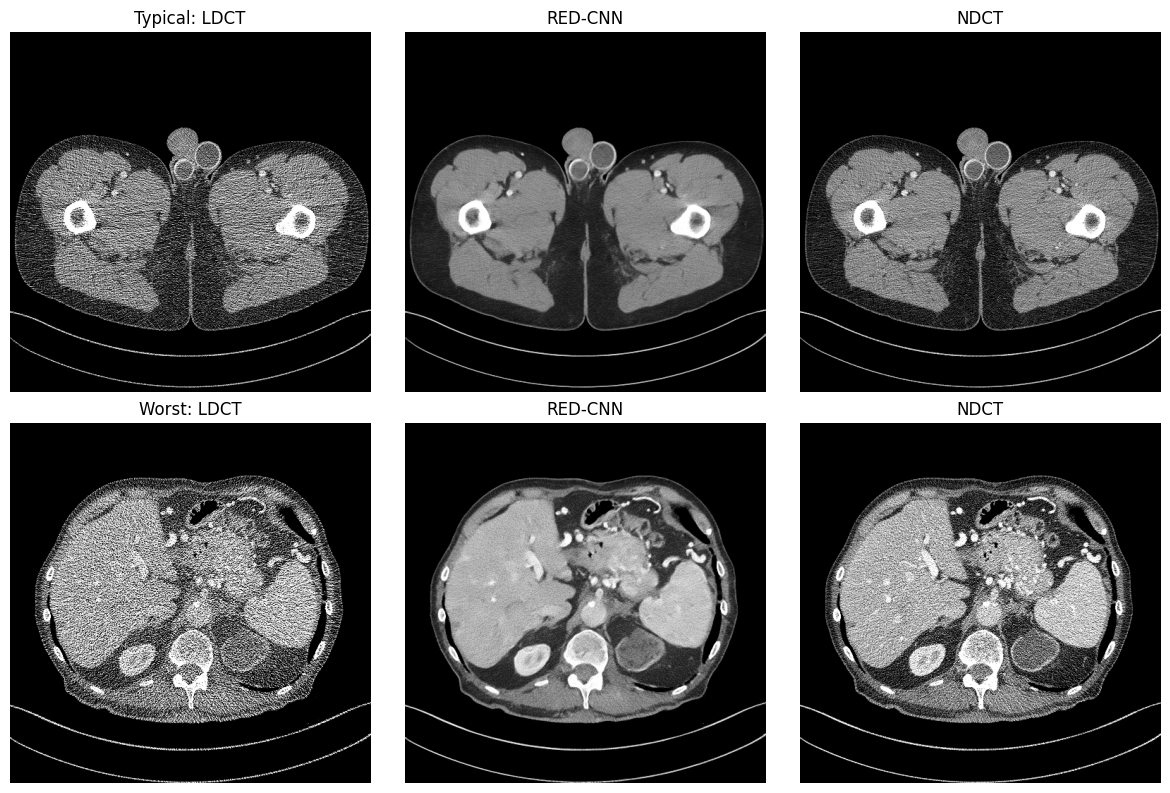

Worst 3 gains (dB): ['5.04', '5.05', '5.05']


In [9]:
gains = [after - before for after, before in zip(test_metrics["psnr_after"], test_metrics["psnr_before"])]
worst_indices = np.argsort(gains)[:3]  # bottom 3 gains -- a single worst slice varied too much between runs to trust
typical_index = len(test_ds.images) // 2

# only fetch actual images for the 4 slices we're about to plot, not all 1000+
typical_input, typical_target, typical_pred = predict_one(model, test_ds, typical_index)
worst_input, worst_target, worst_pred = predict_one(model, test_ds, int(worst_indices[0]))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(typical_input, cmap="gray");  axes[0, 0].set_title("Typical: LDCT")
axes[0, 1].imshow(typical_pred, cmap="gray");   axes[0, 1].set_title("RED-CNN")
axes[0, 2].imshow(typical_target, cmap="gray"); axes[0, 2].set_title("NDCT")

axes[1, 0].imshow(worst_input, cmap="gray");  axes[1, 0].set_title("Worst: LDCT")
axes[1, 1].imshow(worst_pred, cmap="gray");   axes[1, 1].set_title("RED-CNN")
axes[1, 2].imshow(worst_target, cmap="gray"); axes[1, 2].set_title("NDCT")

for row in axes:
    for ax in row:
        ax.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/comparison.png", dpi=120)
plt.show()

print("Worst 3 gains (dB):", [f"{gains[i]:.2f}" for i in worst_indices])

## Critical discussion

- **PSNR numbers here will look low compared to many papers, and that's largely a normalization
  artifact.** A 400 HU window versus a 3000 HU window changes PSNR by ~17 dB for identical underlying
  noise (confirmed directly, see "lessons learned"). Compare relative improvement over this notebook's
  own baseline, not absolute published figures, unless their exact normalization is confirmed.
- **This architecture has a real, small receptive field (~21x21 pixels)** from 5 conv layers with no
  pooling -- a plausible structural contributor to the early training plateau, independent of learning
  rate, and part of why the field moved toward architectures with larger effective context over time.
- **PSNR/SSIM aren't the whole diagnostic story regardless of normalization.** Both were built for
  natural-image quality, not diagnostic usefulness, and don't always agree with each other, let alone
  with radiologist judgment -- this project's own results showed test PSNR coming out lower than
  validation PSNR at the same checkpoint while test SSIM came out higher, a direct example of the two
  metrics disagreeing. A model that improves these numbers by smoothing away fine detail would look
  better here while potentially being worse for actually reading the scan -- the known failure mode of
  MSE-loss training (used above), which is why the field moved toward perceptual/adversarial losses,
  deliberately not attempted here.
- **The "low dose" data is simulated, not independently rescanned.** Quarter-dose images were produced
  by adding Poisson noise to full-dose projection data, not by rescanning the same patient at a lower
  dose -- results are somewhat idealized relative to real deployment.
- **Evaluation split is a single fixed split, not cross-validation**, trading rigor for tractability.
- **What a more rigorous version would add:** a perceptual or adversarial loss term to address
  over-smoothing; full cross-validation instead of one split; a downstream task check (e.g. does
  denoising change measured nodule size/density) rather than only pixel-level metrics; independent
  low-dose acquisitions rather than simulated ones; and a wider architecture search.